In [1]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols

In [9]:
from importlib import reload
reload(protocols)

<module 'helper_functions.protocols' from '/workspaces/Quantum-Communications-Internship-IRIDA-/helper_functions/protocols.py'>

In [16]:
alpha_grid = np.arange(0, 1, 0.01)
N_cs, p_err = protocols.perr_cs(alpha_grid=alpha_grid, homodyne_angle=0, num_samples=1000)

Progress: 100/100

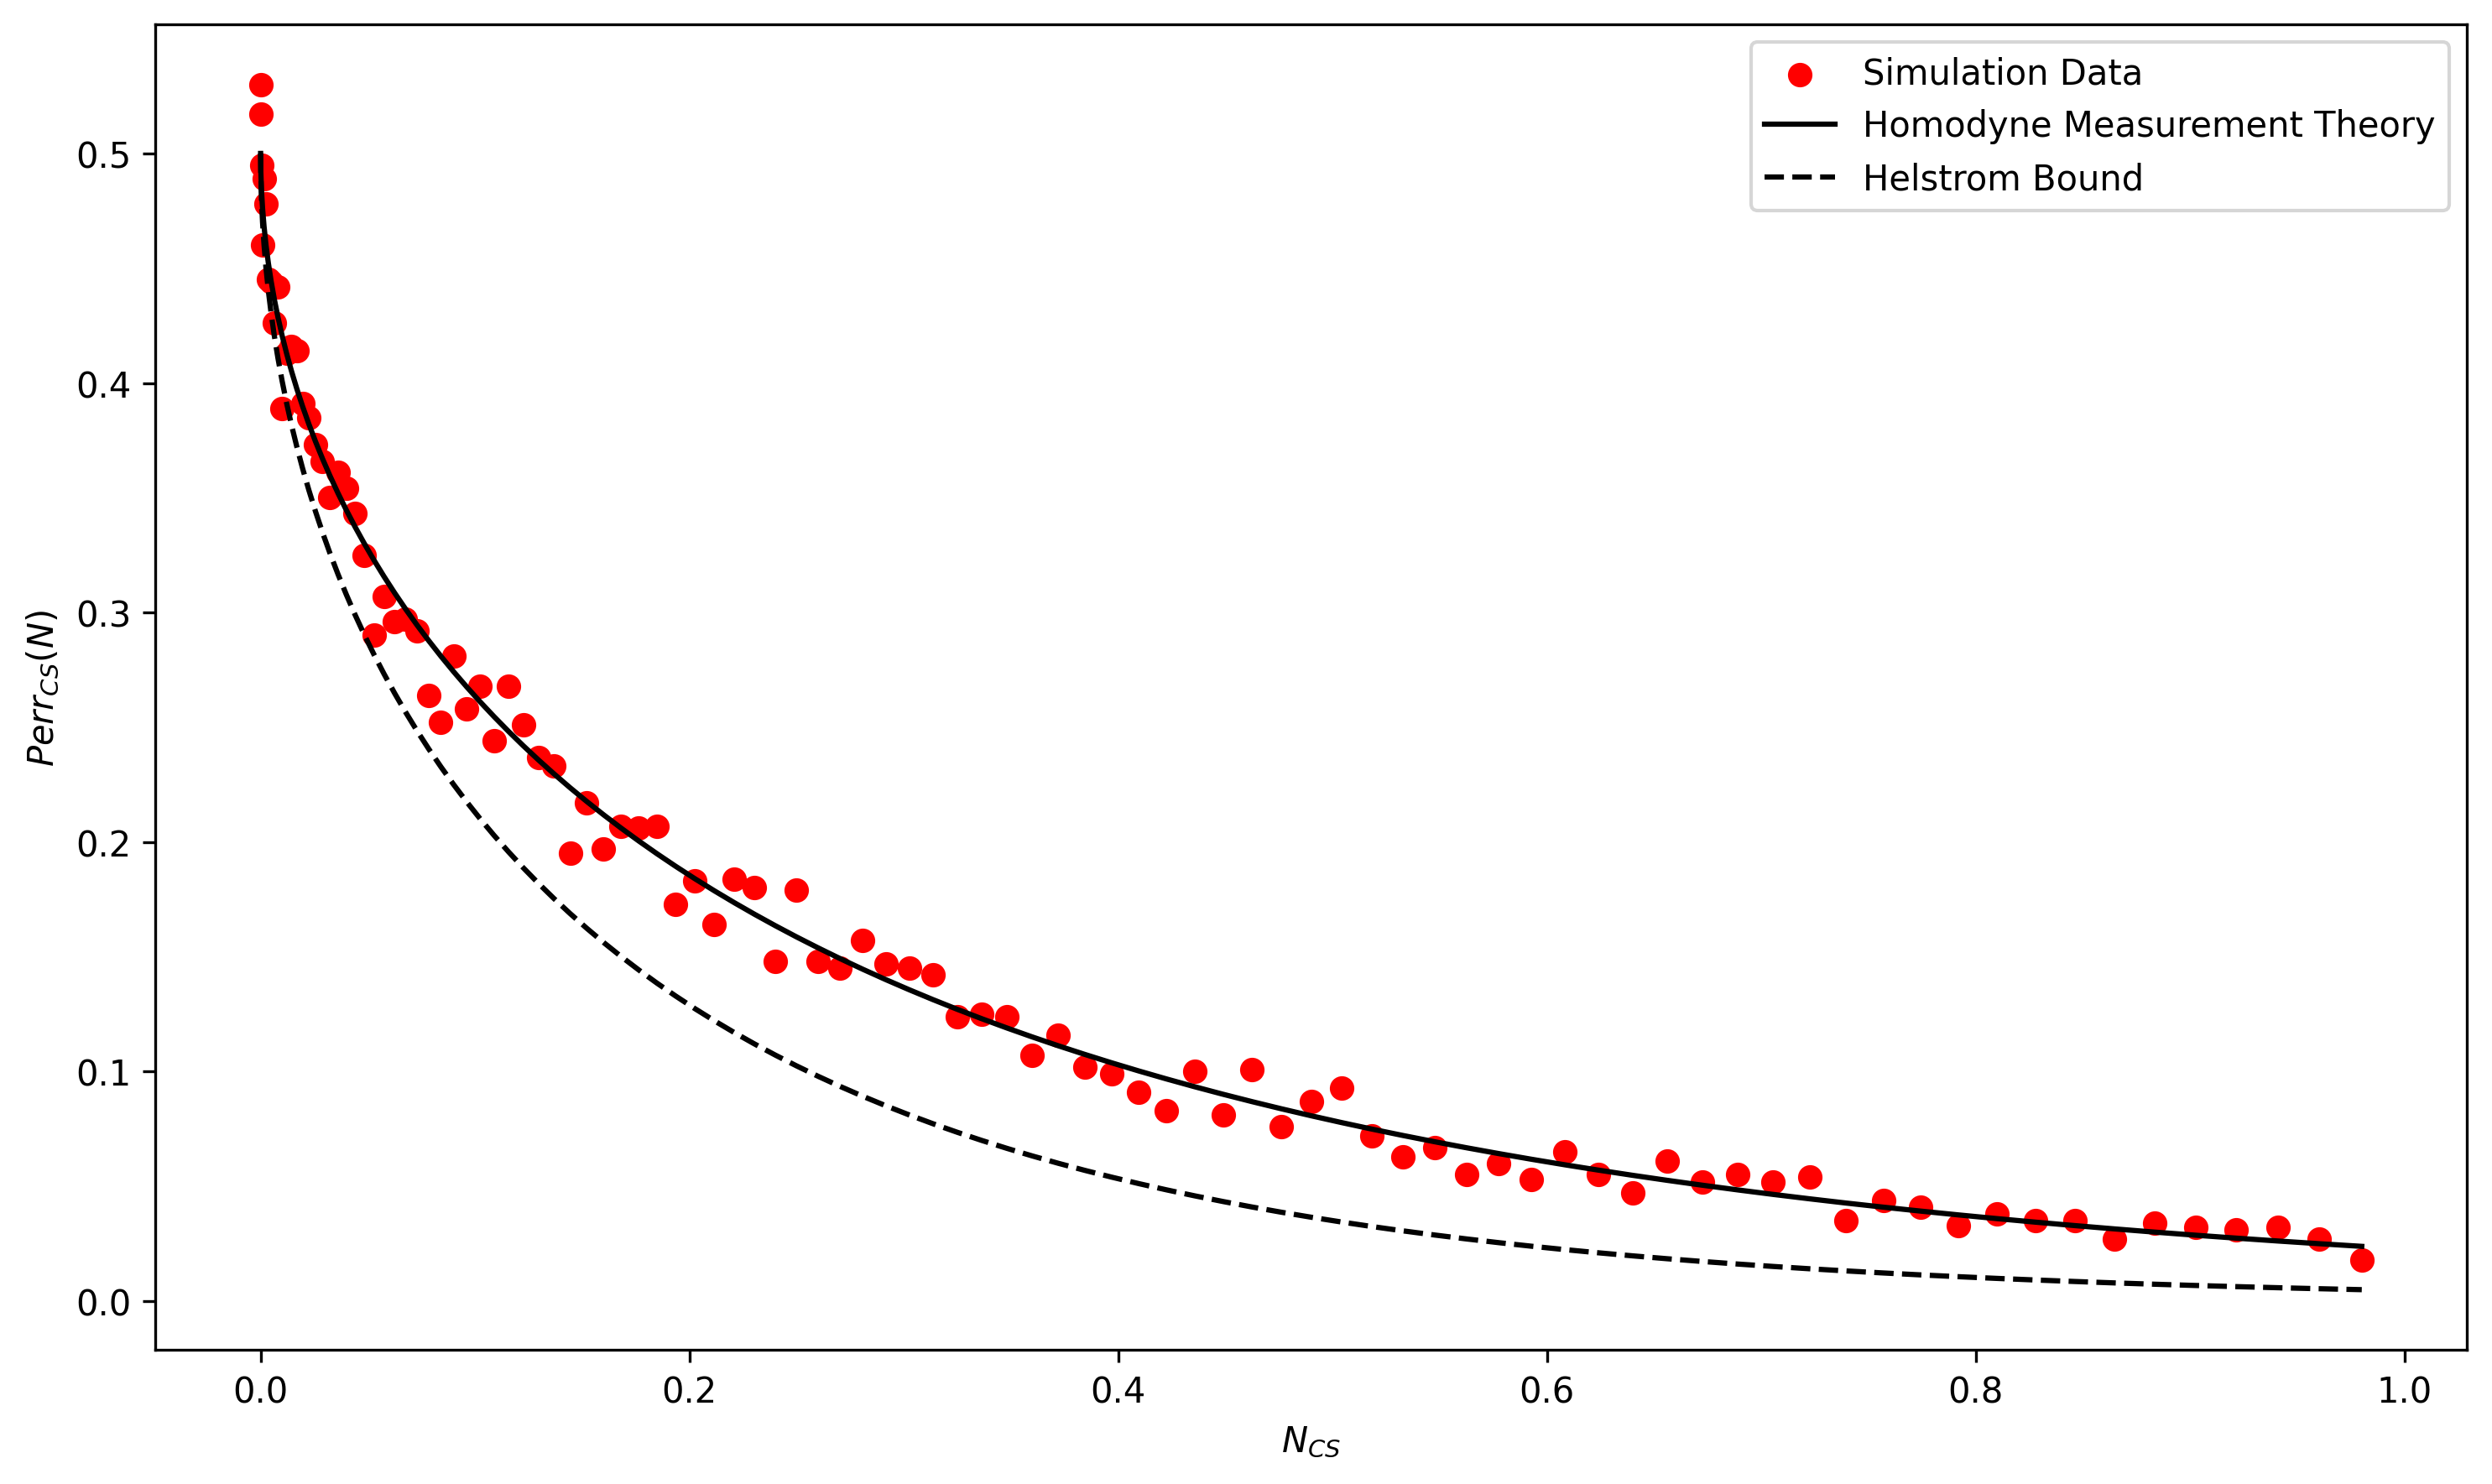

In [17]:
plt.figure(figsize=(10, 6), dpi=300)
plt.ylabel(r"$Perr_{CS}(N)$")
plt.xlabel(r"$N_{CS}$")

plt.scatter(N_cs, p_err, label="Simulation Data", color="red")
plt.plot(N_cs, 0.5 * erfc(np.sqrt(2*N_cs)), label="Homodyne Measurement Theory", color="black")
plt.plot(N_cs, 0.5 * (1 - np.sqrt(1 - np.exp(-4*N_cs))), label="Helstrom Bound", color="black", linestyle="--")

plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
N_grid = np.arange(0, 1, 0.01)
beta_grid = np.arange(0, 1, 0.01)
p_err = protocols.perr_dss(N_grid=N_grid, beta_grid=beta_grid, homodyne_angle=0, num_samples=500)

Progress: 1/100

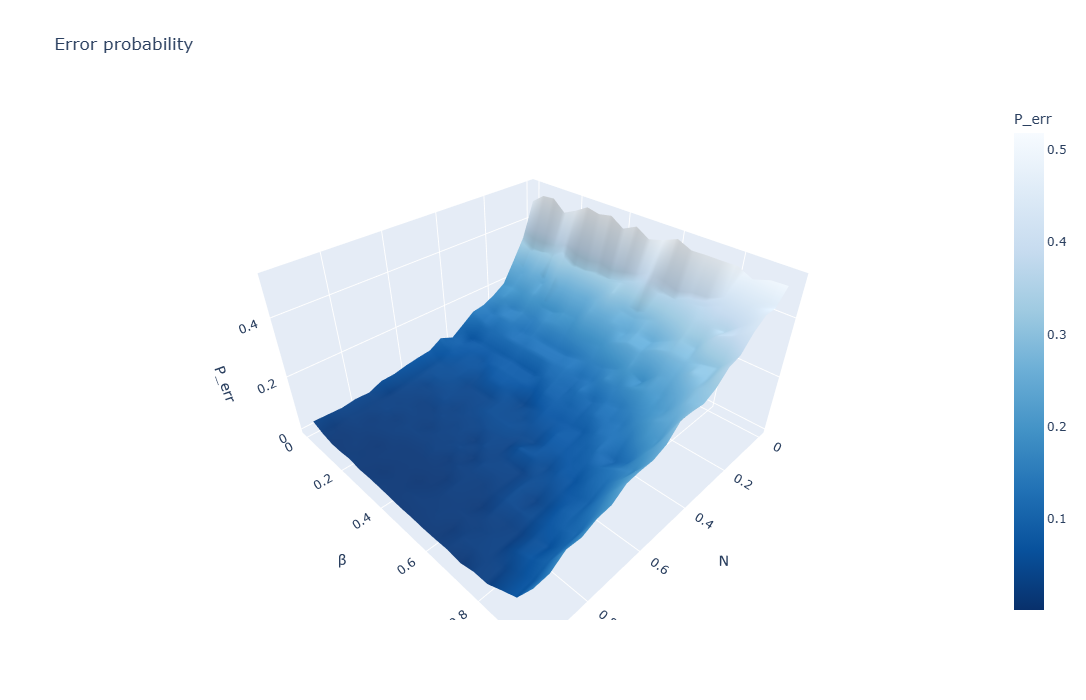

In [30]:
N_mesh, beta_mesh = np.meshgrid(N_grid, beta_grid, indexing='ij')
fig = go.Figure(data=[go.Surface(x=N_mesh, y=beta_mesh, z=p_err, colorscale="Blues_r", colorbar=dict(title="P_err"))])
fig.update_layout(title="Error probability", scene=dict(xaxis_title="N", yaxis_title="β", zaxis_title="P_err"), width=700, height=700)
fig.show()